# Имопорты

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Подготовка данных

In [24]:
df_orig = pd.read_excel('result2022.xlsx')

# Чистим названия колонок
df_orig.columns = [str(c).strip() for c in df_orig.columns]

def clean_and_numeric(df):
    d = df.copy()
    meta = ['VUZ', 'Region', 'Type', 'Site', 'ID', 'year']
    # Конвертация числовых данных 
    for col in d.columns:
        if col not in meta:
            d[col] = d[col].astype(str).str.replace(',', '.').str.replace(' ', '')
            d[col] = pd.to_numeric(d[col], errors='coerce')
    return d

df_working = clean_and_numeric(df_orig)

# Поиск ключевых колонок по смыслу
def find_c(keyword):
    for c in df_working.columns:
        if keyword.lower() in c.lower(): return c
    return None

ege_col = find_c('средний балл егэ')
inc_col = find_c('доходы вуза из всех источников')
stud_col = find_c('общая численность студентов, обучающихся по программам бакалавриата')
sci_col = find_c('объем научно-исследовательских')

# Фильтрация: Оставляем вузы, где балл ЕГЭ > 1 
df_working = df_working[df_working[ege_col] > 1].copy()

In [25]:
# Выделяем только числовые признаки для модели
features = df_working.select_dtypes(include=[np.number]).drop(columns=['ID', 'year'], errors='ignore')

# Удаляем колонки, где более 60% пропусков, остальные заполняем медианой
features = features.dropna(axis=1, thresh=len(features)*0.4).fillna(features.median())

# Обработка асимметрии (Логарифмируем признаки с большими выбросами)
for col in features.columns:
    if features[col].skew() > 1.5:
        features[col] = np.log1p(features[col].clip(lower=0))

# Стандартизация
X_scaled = StandardScaler().fit_transform(features)

# Удаление мультиколлинеарности (убираем почти одинаковые признаки)
corr = pd.DataFrame(X_scaled).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_final_pre = np.delete(X_scaled, to_drop, axis=1)

# PCA (Снижение размерности для визуализации и точности KMeans)
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_final_pre)

# Подбро количества кластеров

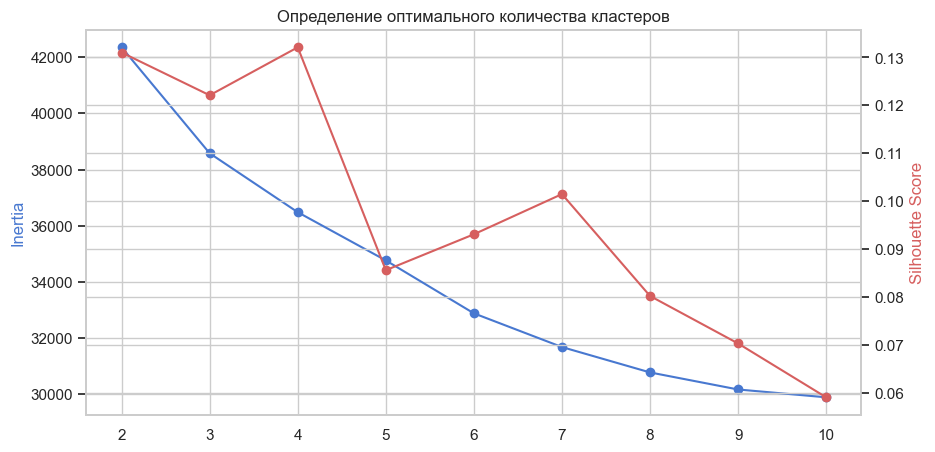

In [26]:
K_range = range(2, 11)
inertia = []
silhouette = []

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_pca)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_pca, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertia, 'bo-', label='Инерция (Локоть)')
ax1.set_ylabel('Inertia', color='b')
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette, 'ro-', label='Силуэт')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('Определение оптимального количества кластеров')
plt.show()


# Кластеризация, 22 год

In [27]:
k_final = 4 
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_working['Cluster'] = kmeans.fit_predict(X_pca)

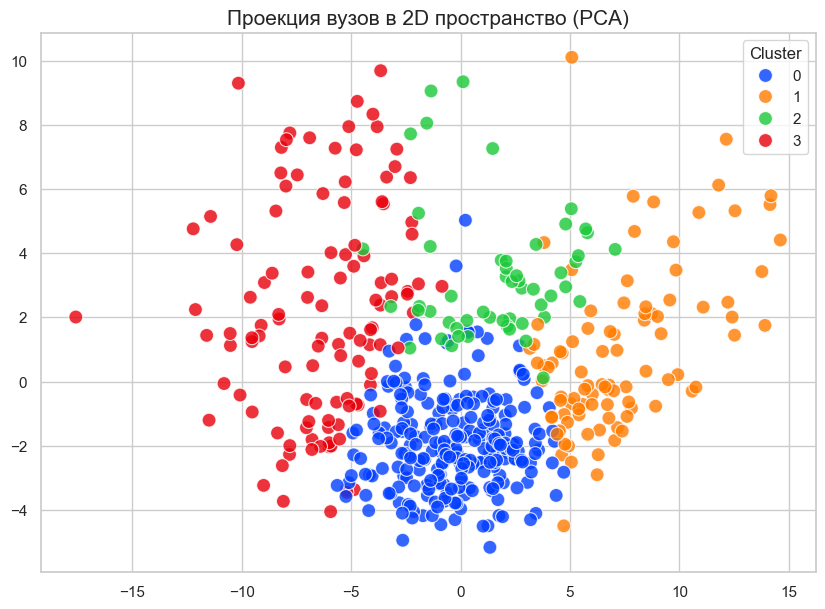

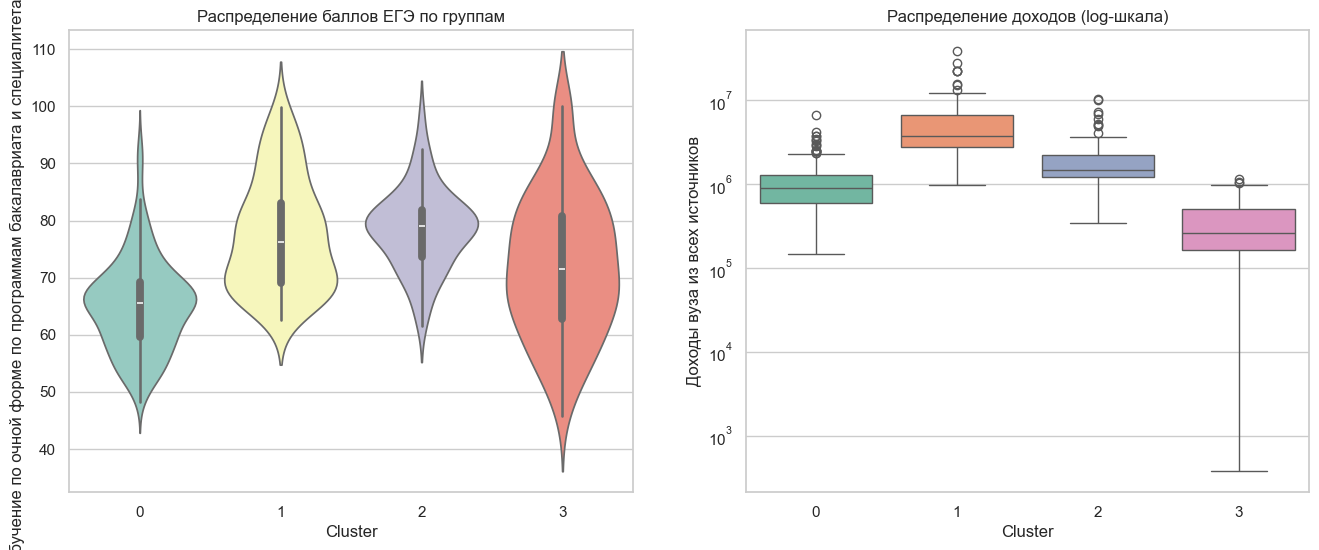

In [28]:
# --- 1. Карта разделения (PCA Scatter) ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_working['Cluster'], 
                palette='bright', s=100, alpha=0.8, edgecolor='w')
plt.title('Проекция вузов в 2D пространство (PCA)', fontsize=15)
plt.show()

# --- 2. Сравнение медиан (Профили) ---
rep_cols = [ege_col, inc_col, stud_col, sci_col]
# Медианы по исходным (не логарифмированным) значениям
medians = df_working.groupby('Cluster')[rep_cols].median()
medians.columns = ['ЕГЭ', 'Доходы', 'Студенты', 'НИОКР']

# --- 3. Скрипичные графики (Распределения) ---
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.violinplot(x='Cluster', y=ege_col, data=df_working, palette='Set3')
plt.title('Распределение баллов ЕГЭ по группам')

plt.subplot(1, 2, 2)
# Для доходов используем логарифмическую шкалу для наглядности
sns.boxplot(x='Cluster', y=inc_col, data=df_working, palette='Set2')
plt.yscale('log')
plt.title('Распределение доходов (log-шкала)')
plt.show()


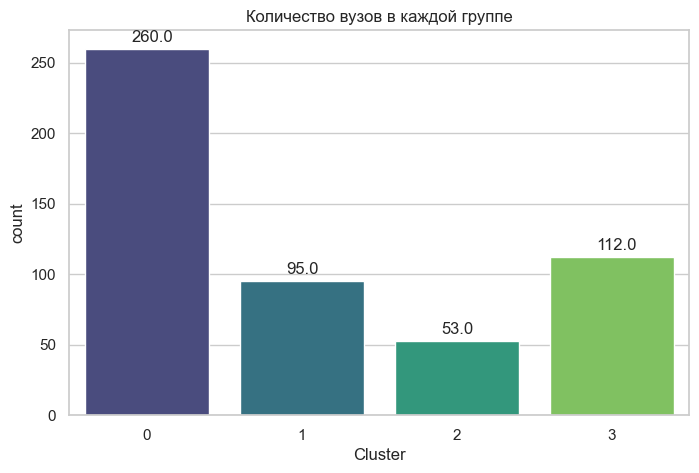

In [29]:
plt.figure(figsize=(8, 5))
count_plot = sns.countplot(x='Cluster', data=df_working, palette='viridis')
for p in count_plot.patches:
    count_plot.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+5))
plt.title('Количество вузов в каждой группе')
plt.show()

In [30]:
display(medians)

,ЕГЭ,Доходы,Студенты,НИОКР
Cluster,,,,
0,65.515,905046.90,5482.0,41643.35
1,76.290,3750391.90,13951.0,498770.10
2,79.110,1488729.20,4594.0,50145.70
3,71.480,265480.15,888.0,8710.35


In [ ]:
for cluster_id in range(k_final):
    # Находим индексы вузов в текущем кластере
    vuz_indices = df_working[df_working['Cluster'] == cluster_id].index
    # Берем оригинальные названия из df_orig по этим индексам
    examples = df_orig.loc[vuz_indices, 'VUZ'].head(20).tolist()
    
    print(f"\nКластер {cluster_id}:")
    print(" -> " + "\n -> ".join(examples))


Кластер 0:
 -> Автономная некоммерческая организация высшего образования "Белгородский университет кооперации, экономики и права"
 -> Автономная некоммерческая организация высшего образования «Российский новый университет»
 -> Аккредитованное образовательное частное учреждение высшего образования «Московский финансово-юридический университет МФЮА»
 -> Государственное бюджетное образовательное учреждение высшего образования Московской области "Технологический университет имени дважды Героя Советского Союза, летчика-космонавта А.А. Леонова"
 -> государственное бюджетное образовательное учреждение высшего образования Московской области "Университет "Дубна"
 -> Государственное казенное образовательное учреждение высшего образования "Российская таможенная академия"
 -> Государственное образовательное учреждение высшего образования Московской области "Государственный гуманитарно-технологический университет"
 -> Государственное образовательное учреждение высшего образования Московской област

# + 2015, 2020, 2021 

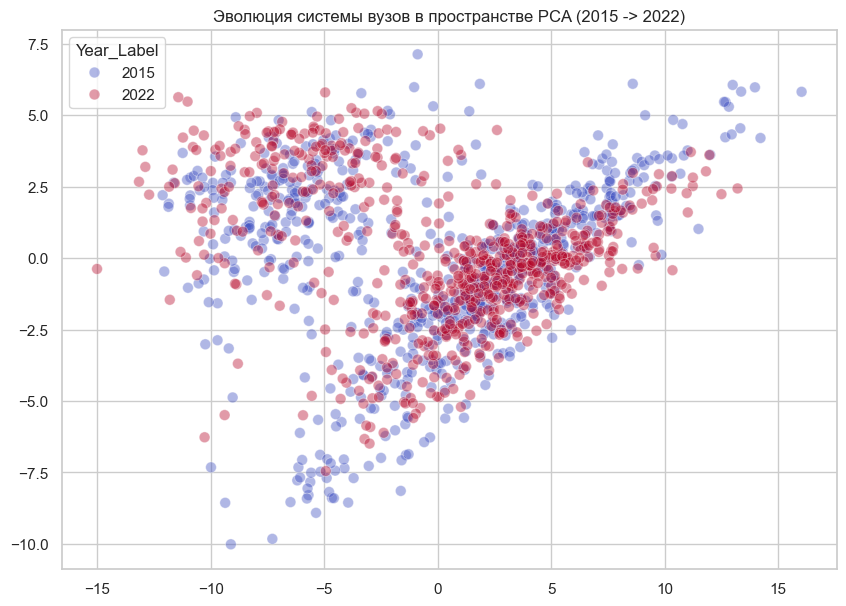

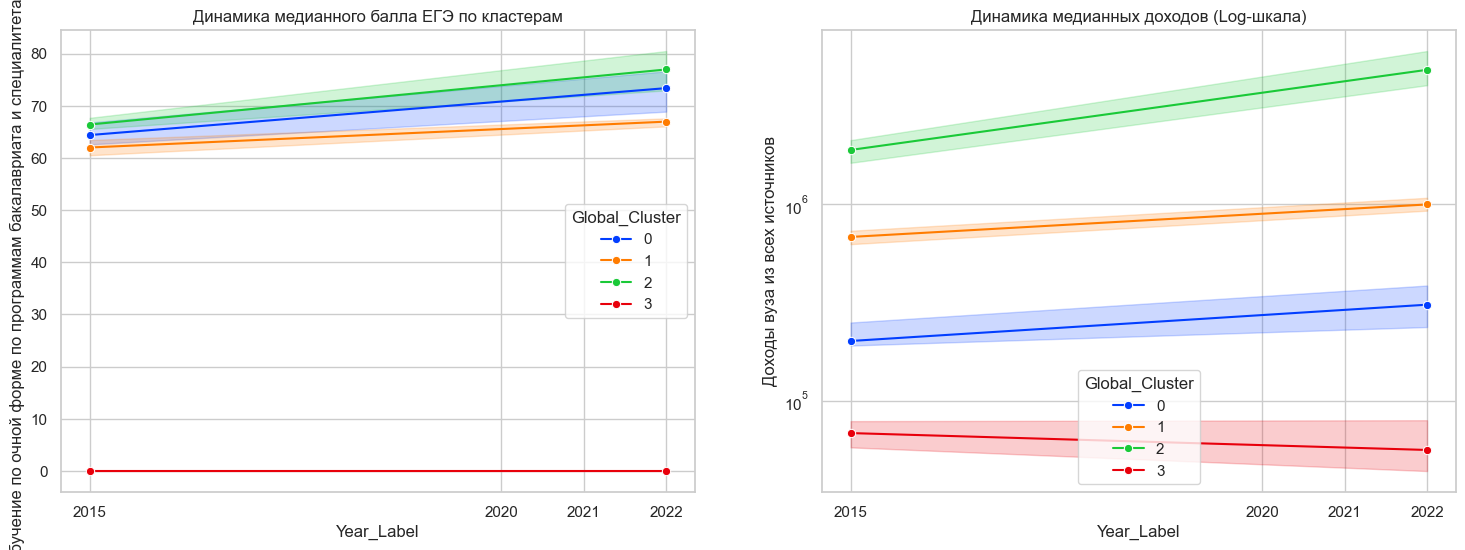

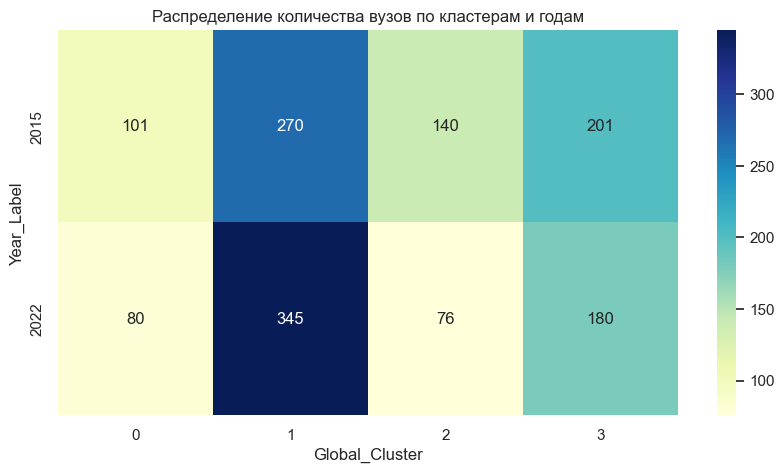

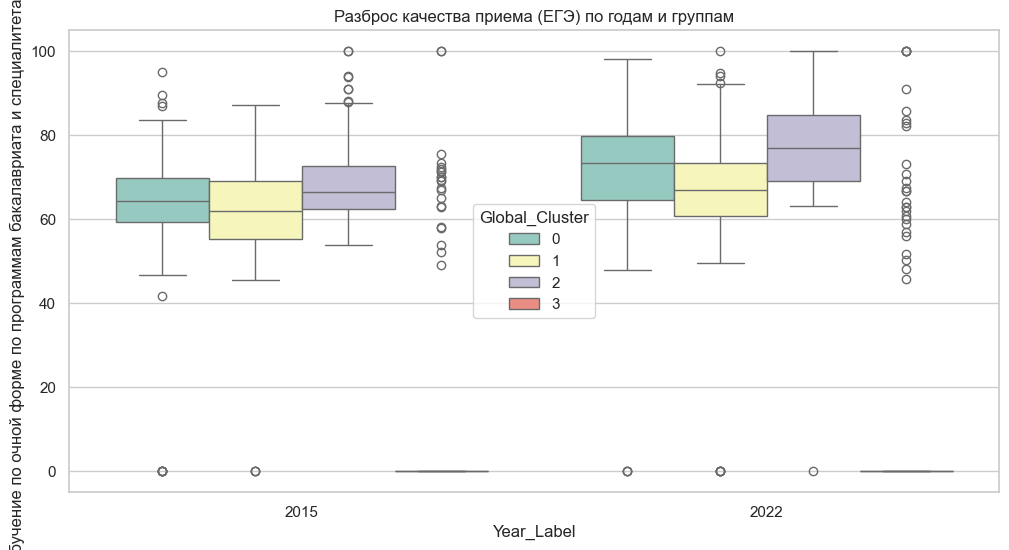


Сравнение состояния кластеров в 2015 и 2022 годах:


Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ  \
Global_Cluster Year_Label                                                                                                                                                                                               
0              2015                                                     64.4                                                                                                                                            
               2022                                                     73.4                                                                                                                                            
1              2015                                                     62.0                                                                                                                                            
               2022                                                     67.0                                                                                                                                            
2              2015                                                     66.4                                                                                                                                            
               2022                                                     76.9                                                                                                                                            
3              2015                                                      0.0                                                                                                                                            
               2022                                                      0.0                                                                                                                                            

                           Доходы вуза из всех источников  
Global_Cluster Year_Label                                  
0              2015                              201773.0  
               2022                              308736.3  
1              2015                              682638.6  
               2022                              998817.6  
2              2015                             1891224.4  
               2022                             4836265.4  
3              2015                               68609.0  
               2022                               56292.0

In [32]:
files = {
    2015: 'result2015.xlsx',
    2020: 'result2020.xlsx',
    2021: 'result2021.xlsx',
    2022: 'result2022.xlsx'
}

all_data_list = []

for year, path in files.items():
    df_temp = pd.read_excel(path)
    df_temp.columns = [str(c).strip() for c in df_temp.columns]
    
    # Конвертируем в числа
    df_temp_num = clean_and_numeric(df_temp)
    # Добавляем метку года
    df_temp_num['Year_Label'] = year
    # Сохраняем название вуза для идентификации
    if 'VUZ' in df_temp.columns:
        df_temp_num['VUZ_Name'] = df_temp['VUZ']
    
    all_data_list.append(df_temp_num)

# Объединяем всё в одну гигантскую таблицу
df_all = pd.concat(all_data_list, axis=0, ignore_index=True)

core_keywords = [
    'средний балл егэ', 
    'доходы вуза из всех источников', 
    'численность студентов', 
    'научно-исследовательских',
    'общая площадь'
]

selected_cols = []
for kw in core_keywords:
    col = find_c(kw) # Используем функцию поиска из предыдущего кода
    if col: selected_cols.append(col)

# Оставляем только те данные, где есть ключевые показатели
df_all_filtered = df_all.dropna(subset=[ege_col, inc_col])

features_all = df_all_filtered.select_dtypes(include=[np.number]).drop(columns=['ID', 'year', 'Year_Label'], errors='ignore')
features_all = features_all.dropna(axis=1, thresh=len(features_all)*0.5).fillna(features_all.median())

# Логарифмирование
for col in features_all.columns:
    if features_all[col].skew() > 1.5:
        features_all[col] = np.log1p(features_all[col].clip(lower=0))

X_scaled_all = StandardScaler().fit_transform(features_all)
X_pca_all = PCA(n_components=0.9, random_state=42).fit_transform(X_scaled_all)

k_all = 4
kmeans_all = KMeans(n_clusters=k_all, random_state=42, n_init=10)
df_all_filtered['Global_Cluster'] = kmeans_all.fit_predict(X_pca_all)


plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_all[:, 0], y=X_pca_all[:, 1], hue=df_all_filtered['Year_Label'], 
                palette='coolwarm', s=60, alpha=0.4)
plt.title('Эволюция системы вузов в пространстве PCA (2015 -> 2022)')
plt.show()

# Как менялся ЕГЭ и Доходы в разных кластерах 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=df_all_filtered, x='Year_Label', y=ege_col, hue='Global_Cluster', 
             marker='o', palette='bright', ax=ax1, estimator='median')
ax1.set_title('Динамика медианного балла ЕГЭ по кластерам')
ax1.set_xticks([2015, 2020, 2021, 2022])

sns.lineplot(data=df_all_filtered, x='Year_Label', y=inc_col, hue='Global_Cluster', 
             marker='o', palette='bright', ax=ax2, estimator='median')
ax2.set_yscale('log')
ax2.set_title('Динамика медианных доходов (Log-шкала)')
ax2.set_xticks([2015, 2020, 2021, 2022])

plt.show()

# Тепловая карта  (Кто в каком кластере по годам)
pivot_counts = pd.crosstab(df_all_filtered['Year_Label'], df_all_filtered['Global_Cluster'])
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Распределение количества вузов по кластерам и годам')
plt.show()

# Разброс ЕГЭ по годам 
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year_Label', y=ege_col, hue='Global_Cluster', data=df_all_filtered, palette='Set3')
plt.title('Разброс качества приема (ЕГЭ) по годам и группам')
plt.show()

print("\nСравнение состояния кластеров в 2015 и 2022 годах:")
compare_report = df_all_filtered[df_all_filtered['Year_Label'].isin([2015, 2022])].groupby(['Global_Cluster', 'Year_Label'])[[ege_col, inc_col]].median().round(1)
display(compare_report)

In [44]:
def print_cluster_examples(df, cluster_col, title):
    print(f"\n{'='*20} {title} {'='*20}")
    for cluster_id in sorted(df[cluster_col].unique()):
        # Берем вузы, у которых есть название
        vuzes = df[df[cluster_col] == cluster_id]['VUZ_Name'].unique()[:5]
        print(f"Кластер {cluster_id}:")
        for v in vuzes:
            print(f"  - {v}")

# Для анализа 2022 (используем df_working, где мы сохранили VUZ_Name)
# Если в df_working нет VUZ_Name, возьмем из df_orig по индексам
df_working['VUZ_Name'] = df_orig.loc[df_working.index, 'VUZ']
print_cluster_examples(df_working, 'Cluster', 'ПРИМЕРЫ ВУЗОВ: АНАЛИЗ 2022')

# Для глобального анализа
print_cluster_examples(df_all_filtered, 'Global_Cluster', 'ПРИМЕРЫ ВУЗОВ:  (2015-2022)')


# Выберем несколько заметных вузов для демонстрации (Лидеры, средние и т.д.)
# Можно настроить список под свои нужды
target_vuz_list = [
    'Московский государственный университет имени М.В.Ломоносова',
    'Национальный исследовательский университет "Высшая школа экономики"',
    'Московский физико-технический институт (национальный исследовательский университет)',
    'Белгородский государственный национальный исследовательский университет',
    'Воронежский экономико-правовой институт'
]

# Создаем сводную таблицу по выбранным вузам
# Так как названия могут чуть отличаться, используем поиск по части строки
final_tracking = []

for vuz_pattern in target_vuz_list:
    # Ищем вуз в общей базе (df_all_filtered)
    vuz_data = df_all_filtered[df_all_filtered['VUZ_Name'].str.contains(vuz_pattern[:20], na=False, case=False)]
    
    if not vuz_data.empty:
        for year in [2015, 2022]:
            year_row = vuz_data[vuz_data['Year_Label'] == year]
            if not year_row.empty:
                final_tracking.append({
                    'Вуз': vuz_pattern[:40] + '...', # Сокращаем название для таблицы
                    'Год': year,
                    'Кластер': year_row['Global_Cluster'].values[0],
                    'ЕГЭ': year_row[ege_col].values[0],
                    'Доходы (млн)': round(year_row[inc_col].values[0] / 1e6, 2) if year_row[inc_col].values[0] > 10000 else year_row[inc_col].values[0]
                })

df_tracking = pd.DataFrame(final_tracking)
if not df_tracking.empty:
    # Сделаем красивый pivot для сравнения
    tracking_pivot = df_tracking.pivot(index='Вуз', columns='Год', values=['Кластер', 'ЕГЭ'])
    display(tracking_pivot)
else:
    print("Вузы из списка не найдены в отфильтрованных данных.")


==================== ПРИМЕРЫ ВУЗОВ: АНАЛИЗ 2022 ====================
Кластер 0:
  - Автономная некоммерческая организация высшего образования "Белгородский университет кооперации, экономики и права"
  - Автономная некоммерческая организация высшего образования «Российский новый университет»
  - Аккредитованное образовательное частное учреждение высшего образования «Московский финансово-юридический университет МФЮА»
  - Государственное бюджетное образовательное учреждение высшего образования Московской области "Технологический университет имени дважды Героя Советского Союза, летчика-космонавта А.А. Леонова"
  - государственное бюджетное образовательное учреждение высшего образования Московской области "Университет "Дубна"
Кластер 1:
  - Государственное автономное образовательное учреждение высшего образования города Москвы "Московский городской педагогический университет"
  - Государственное образовательное учреждение высшего образования Московской области Московский государственный об

Кластер         ЕГЭ       
Год                                            2015 2022   2015   2022
Вуз                                                                   
Белгородский государственный национальны...     1.0  0.0  54.10  72.80
Воронежский экономико-правовой институт...      3.0  3.0   0.00   0.00
Московский государственный университет и...     0.0  1.0  64.06  61.53
Московский физико-технический институт (...     2.0  2.0  93.83  97.87
Национальный исследовательский университ...     2.0  2.0  65.76  97.87

Year_Label,2015,2022,Diff
VUZ_Name,,,
"Федеральное государственное бюджетное образовательное учреждение высшего образования ""Академия акварели и изящных искусств Сергея Андрияки""",66.70,79.80,13.10
Федеральное государственное автономное образовательное учреждение высшего образования «Национальный исследовательский Томский государственный университет»,71.40,80.55,9.15
"федеральное государственное бюджетное образовательное учреждение высшего образования ""Российская государственная специализированная академия искусств""",68.51,77.46,8.95
Федеральное государственное бюджетное образовательное учреждение высшего образования «Государственный университет морского и речного флота имени адмирала С.О. Макарова»,60.75,69.48,8.73
федеральное государственное бюджетное образовательное учреждение высшего образования «Национальный исследовательский университет «МЭИ»,64.63,72.71,8.08


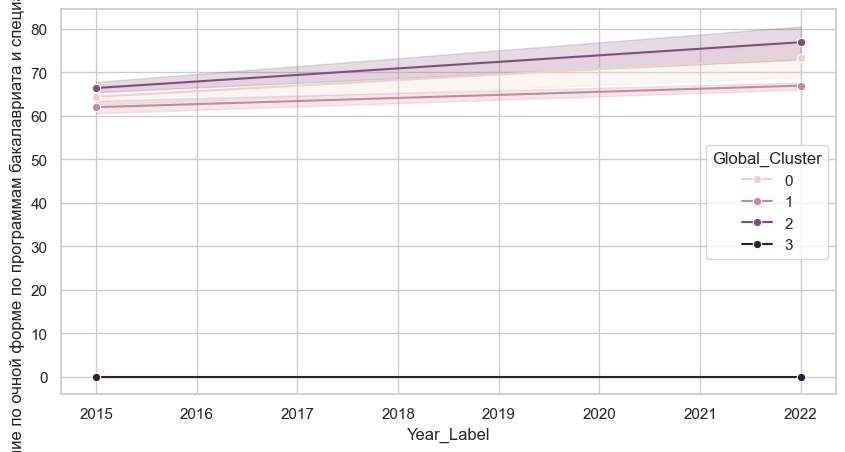

In [37]:
vuz_growth = df_all_filtered.pivot(index='VUZ_Name', columns='Year_Label', values=ege_col)
if 2015 in vuz_growth.columns and 2022 in vuz_growth.columns:
    # Оставляем только те вузы, где в 2015 балл был > 10 (отсекаем ошибки сопоставления)
    valid_growth = vuz_growth[vuz_growth[2015] > 10].copy()
    valid_growth['Diff'] = valid_growth[2022] - valid_growth[2015]
    
    display(valid_growth.sort_values(by='Diff', ascending=False).head(5))

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_all_filtered, x='Year_Label', y=ege_col, hue='Global_Cluster', marker='o', estimator='median')
plt.show()